# Marketing ROI – Feature Engineering

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv(
    "../data/raw/marketing_roi_dataset.csv",
    parse_dates=["date"]
)

df.sort_values("date", inplace=True)
df.reset_index(drop=True, inplace=True)

In [3]:
df_clean = df

In [4]:
features = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions"
]

for col in features:
    df_clean[f"{col}_missing"] = df[col].isna().astype(int)

In [5]:
for col in features:
    df_clean[col] = df[col].fillna(df[col].median())

In [6]:
df.isna().sum()

date                             0
google_ads_spend                 0
facebook_ads_spend               0
email_marketing_spend            0
influencer_spend                 0
organic_traffic                  0
email_sends                      0
site_visits                      0
conversions                      0
revenue                          0
google_ads_spend_missing         0
facebook_ads_spend_missing       0
email_marketing_spend_missing    0
influencer_spend_missing         0
organic_traffic_missing          0
email_sends_missing              0
site_visits_missing              0
conversions_missing              0
dtype: int64

In [7]:
skewed_vars = [
    "google_ads_spend",
    "facebook_ads_spend",
    "email_marketing_spend",
    "influencer_spend",
]

In [8]:
for col in skewed_vars:
    df_clean[f"{col}_log"] = np.log1p(df_clean[col])

In [9]:
scaler = RobustScaler()

prediction_vars = [
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    "email_marketing_spend_log",
    "influencer_spend_log",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions"
]

df_clean[prediction_vars] = scaler.fit_transform(df_clean[prediction_vars])

In [10]:
df_clean = df_clean[[    
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    "email_marketing_spend_log",
    "influencer_spend_log",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions",
    "revenue",
    "google_ads_spend_missing",
    "facebook_ads_spend_missing",
    "email_marketing_spend_missing",
    "influencer_spend_missing",
    "organic_traffic_missing",
    "email_sends_missing",
    "site_visits_missing",
    "conversions_missing",
    "date"
    ]]

In [11]:
df_clean.describe().T

,count,mean,min,25%,50%,75%,max,std
google_ads_spend_log,1000.0,-0.055262,-3.733467,-0.536499,0.0,0.463501,3.751916,0.844008
facebook_ads_spend_log,1000.0,-0.099346,-4.159906,-0.567981,0.0,0.432019,2.914763,0.852764
email_marketing_spend_log,1000.0,-0.104367,-3.347855,-0.535094,0.0,0.464906,1.862944,0.806265
influencer_spend_log,1000.0,-0.075548,-2.826531,-0.510998,0.0,0.489002,1.802958,0.764902
organic_traffic,1000.0,0.015302,-2.872945,-0.472514,0.0,0.527486,2.564091,0.777415
email_sends,1000.0,0.003291,-2.096692,-0.496237,0.0,0.503763,2.586222,0.787703
site_visits,1000.0,-0.01804,-3.274815,-0.518241,0.0,0.481759,2.419022,0.784002
conversions,1000.0,0.026748,-2.606786,-0.462385,0.0,0.537615,2.264355,0.749274
revenue,1000.0,2433.043276,-16329.076524,-916.706634,2421.080779,5894.710904,31589.536448,5309.341622
google_ads_spend_missing,1000.0,0.05,0.0,0.0,0.0,0.0,1.0,0.218054


In [12]:
df_clean = df_clean.sort_values("date").reset_index(drop=True)

lag_vars = [
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    "email_marketing_spend_log",
    "influencer_spend_log",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions",
]

lags = [1, 3, 7]

for col in lag_vars:
    for lag in lags:
        df_clean[f"{col}_lag{lag}"] = df_clean[col].shift(lag)

In [13]:
df_clean = df_clean.sort_values("date").reset_index(drop=True)

In [14]:
lag_vars = [
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    "email_marketing_spend_log",
    "influencer_spend_log",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions",
]

lags = [1, 3, 7]

In [15]:
for col in lag_vars:
    for lag in lags:
        lag_col = f"{col}_lag{lag}"
        missing_col = f"{lag_col}_missing"
        
        # Create lag
        df_clean[lag_col] = df_clean[col].shift(lag)
        
        # Missing indicator (1 if missing, else 0)
        df_clean[missing_col] = df_clean[lag_col].isna().astype(int)
        
        # Fill missing lag values with 0
        df_clean[lag_col] = df_clean[lag_col].fillna(0)

In [16]:
df_clean

,google_ads_spend_log,facebook_ads_spend_log,email_marketing_spend_log,influencer_spend_log,organic_traffic,email_sends,site_visits,conversions,revenue,google_ads_spend_missing,facebook_ads_spend_missing,email_marketing_spend_missing,influencer_spend_missing,organic_traffic_missing,email_sends_missing,site_visits_missing,conversions_missing,date,google_ads_spend_log_lag1,google_ads_spend_log_lag3,google_ads_spend_log_lag7,facebook_ads_spend_log_lag1,facebook_ads_spend_log_lag3,facebook_ads_spend_log_lag7,email_marketing_spend_log_lag1,email_marketing_spend_log_lag3,email_marketing_spend_log_lag7,influencer_spend_log_lag1,influencer_spend_log_lag3,influencer_spend_log_lag7,organic_traffic_lag1,organic_traffic_lag3,organic_traffic_lag7,email_sends_lag1,email_sends_lag3,email_sends_lag7,site_visits_lag1,site_visits_lag3,site_visits_lag7,conversions_lag1,conversions_lag3,conversions_lag7,google_ads_spend_log_lag1_missing,google_ads_spend_log_lag3_missing,google_ads_spend_log_lag7_missing,facebook_ads_spend_log_lag1_missing,facebook_ads_spend_log_lag3_missing,facebook_ads_spend_log_lag7_missing,email_marketing_spend_log_lag1_missing,email_marketing_spend_log_lag3_missing,email_marketing_spend_log_lag7_missing,influencer_spend_log_lag1_missing,influencer_spend_log_lag3_missing,influencer_spend_log_lag7_missing,organic_traffic_lag1_missing,organic_traffic_lag3_missing,organic_traffic_lag7_missing,email_sends_lag1_missing,email_sends_lag3_missing,email_sends_lag7_missing,site_visits_lag1_missing,site_visits_lag3_missing,site_visits_lag7_missing,conversions_lag1_missing,conversions_lag3_missing,conversions_lag7_missing
0,0.330639,-1.497778,0.508957,-0.042318,-0.431001,0.096983,-1.480853,-0.705973,-8969.378951,0,0,0,0,0,0,0,0,2024-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,-0.172202,-0.134738,0.000000,-0.776036,0.362508,0.668100,0.820817,0.243462,4996.218917,0,0,1,0,0,0,0,0,2024-01-02,0.330639,0.000000,0.000000,-1.497778,0.000000,0.000000,0.508957,0.000000,0.000000,-0.042318,0.000000,0.000000,-0.431001,0.000000,0.000000,0.096983,0.000000,0.000000,-1.480853,0.000000,0.000000,-0.705973,0.000000,0.000000,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1
2,-0.255385,0.002005,-0.962783,-0.460985,-2.276035,0.640554,0.772678,-0.949354,4703.488945,0,0,0,0,0,0,0,0,2024-01-03,-0.172202,0.000000,0.000000,-0.134738,0.000000,0.000000,0.000000,0.000000,0.000000,-0.776036,0.000000,0.000000,0.362508,0.000000,0.000000,0.668100,0.000000,0.000000,0.820817,0.000000,0.000000,0.243462,0.000000,0.000000,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1,0,1,1
3,-0.255371,-1.563605,-0.254954,-1.385825,0.788624,-1.191803,0.683390,0.066782,1857.547269,0,0,0,0,0,0,0,0,2024-01-04,-0.255385,0.330639,0.000000,0.002005,-1.497778,0.000000,-0.962783,0.508957,0.000000,-0.460985,-0.042318,0.000000,-2.276035,-0.431001,0.000000,0.640554,0.096983,0.000000,0.772678,-1.480853,0.000000,-0.949354,-0.705973,0.000000,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1
4,1.040750,-0.331261,-1.435837,1.081788,1.101198,1.558699,0.302509,0.359725,7763.494686,0,0,0,0,0,0,0,0,2024-01-05,-0.255371,-0.172202,0.000000,-1.563605,-0.134738,0.000000,-0.254954,0.000000,0.000000,-1.385825,-0.776036,0.000000,0.788624,0.362508,0.000000,-1.191803,0.668100,0.000000,0.683390,0.820817,0.000000,0.066782,0.243462,0.000000,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.108257,-0.064812,0.076030,-0.119880,-0.122464,0.089680,0.896867,-0.181835,5330.867668,0,0,0,0,0,0,0,0,2026-09-22,-0.020050,-1.751987,0.917369,1.297189,0.201

In [17]:
df_clean[[c for c in df_clean.columns if c.endswith("_missing")]].mean().sort_values(ascending=False)

google_ads_spend_missing                  0.050
email_marketing_spend_missing             0.050
influencer_spend_missing                  0.050
organic_traffic_missing                   0.050
email_sends_missing                       0.050
site_visits_missing                       0.050
conversions_missing                       0.050
facebook_ads_spend_missing                0.050
facebook_ads_spend_log_lag7_missing       0.007
site_visits_lag7_missing                  0.007
email_sends_lag7_missing                  0.007
organic_traffic_lag7_missing              0.007
influencer_spend_log_lag7_missing         0.007
email_marketing_spend_log_lag7_missing    0.007
conversions_lag7_missing                  0.007
google_ads_spend_log_lag7_missing         0.007
site_visits_lag3_missing                  0.003
facebook_ads_spend_log_lag3_missing       0.003
conversions_lag3_missing                  0.003
influencer_spend_log_lag3_missing         0.003
organic_traffic_lag3_missing            

In [18]:
df_clean.filter(like="_lag").describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
google_ads_spend_log_lag1,1000.0,-0.054577,0.843775,-3.733467,-0.532441,0.0,0.463501,3.751916
google_ads_spend_log_lag3,1000.0,-0.054145,0.843692,-3.733467,-0.532441,0.0,0.463501,3.751916
google_ads_spend_log_lag7,1000.0,-0.054293,0.842607,-3.733467,-0.529498,0.0,0.462427,3.751916
facebook_ads_spend_log_lag1,1000.0,-0.099372,0.852760,-4.159906,-0.567981,0.0,0.432019,2.914763
facebook_ads_spend_log_lag3,1000.0,-0.100059,0.852371,-4.159906,-0.567981,0.0,0.429723,2.914763
facebook_ads_spend_log_lag7,1000.0,-0.100250,0.850958,-4.159906,-0.563709,0.0,0.428343,2.914763
email_marketing_spend_log_lag1,1000.0,-0.104625,0.806191,-3.347855,-0.535094,0.0,0.464906,1.862944
email_marketing_spend_log_lag3,1000.0,-0.105130,0.805966,-3.347855,-0.535094,0.0,0.463393,1.862944
email_marketing_spend_log_lag7,1000.0,-0.102166,0.803461,-3.347855,-0.531398,0.0,0.463393,1.862944
influencer_spend_log_lag1,1000.0,-0.075910,0.764781,-2.826531,-0.510998,0.0,0.489002,1.802958


In [19]:
lagged_features = [
    c for c in df_clean.columns 
    if "_lag" in c and not c.endswith("_missing")
]

corr_df = (
    df_clean[lagged_features + ["revenue"]]
    .corr()["revenue"]
    .drop("revenue")
    .sort_values(key=abs, ascending=False)
)

corr_df

facebook_ads_spend_log_lag7      -0.041388
conversions_lag3                 -0.032231
email_sends_lag3                  0.029713
email_sends_lag1                 -0.029580
influencer_spend_log_lag7        -0.026143
organic_traffic_lag7             -0.025219
site_visits_lag7                 -0.018655
email_marketing_spend_log_lag1    0.015746
organic_traffic_lag1              0.014566
email_marketing_spend_log_lag7   -0.013724
organic_traffic_lag3              0.012648
email_sends_lag7                  0.012635
site_visits_lag1                 -0.011849
facebook_ads_spend_log_lag3       0.008323
influencer_spend_log_lag3        -0.008166
influencer_spend_log_lag1        -0.008019
google_ads_spend_log_lag1        -0.007887
facebook_ads_spend_log_lag1      -0.007215
site_visits_lag3                  0.006346
google_ads_spend_log_lag3         0.004653
conversions_lag7                 -0.003262
email_marketing_spend_log_lag3   -0.002047
google_ads_spend_log_lag7         0.001903
conversions

In [20]:
base_vars = [
    "google_ads_spend_log",
    "facebook_ads_spend_log",
    "email_marketing_spend_log",
    "influencer_spend_log",
    "organic_traffic",
    "email_sends",
    "site_visits",
    "conversions",
]

rows = []

for var in base_vars:
    rows.append({
        "feature": var,
        "corr": df_clean[var].corr(df_clean["revenue"])
    })
    for lag in [1, 3, 7]:
        rows.append({
            "feature": f"{var}_lag{lag}",
            "corr": df_clean[f"{var}_lag{lag}"].corr(df_clean["revenue"])
        })

corr_comparison = (
    pd.DataFrame(rows)
    .assign(abs_corr=lambda x: x["corr"].abs())
    .sort_values("feature", ascending=False)
)

corr_comparison.head(20)

,feature,corr,abs_corr
27,site_visits_lag7,-0.018655,0.018655
26,site_visits_lag3,0.006346,0.006346
25,site_visits_lag1,-0.011849,0.011849
24,site_visits,-0.024584,0.024584
19,organic_traffic_lag7,-0.025219,0.025219
18,organic_traffic_lag3,0.012648,0.012648
17,organic_traffic_lag1,0.014566,0.014566
16,organic_traffic,0.007256,0.007256
15,influencer_spend_log_lag7,-0.026143,0.026143
14,influencer_spend_log_lag3,-0.008166,0.008166


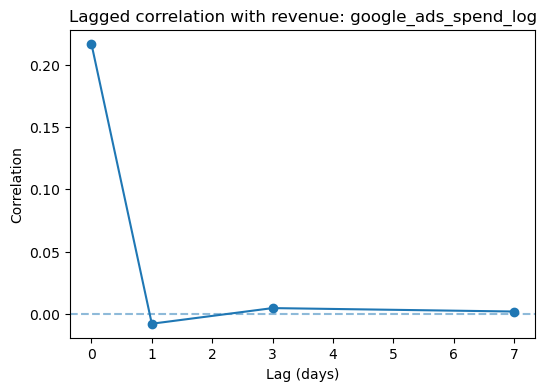

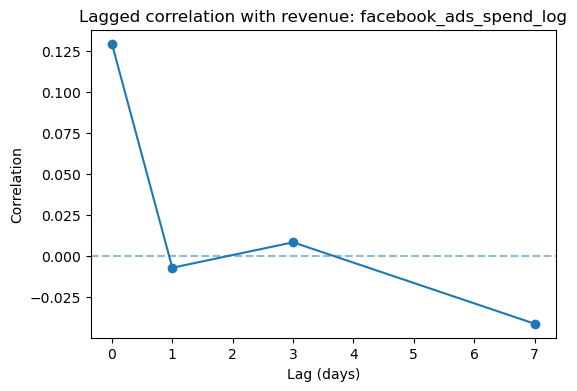

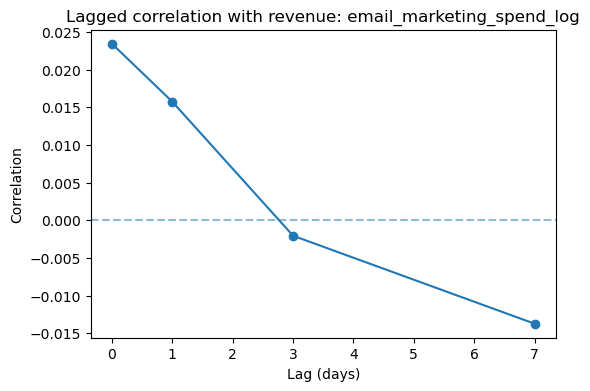

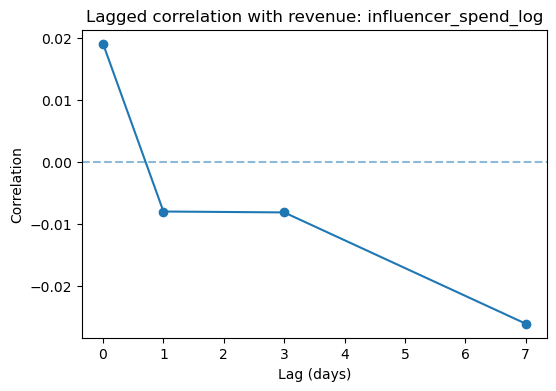

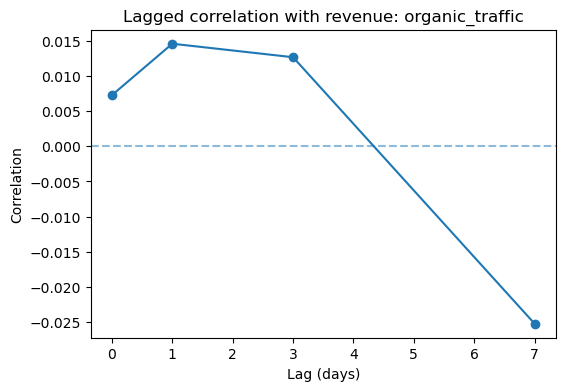

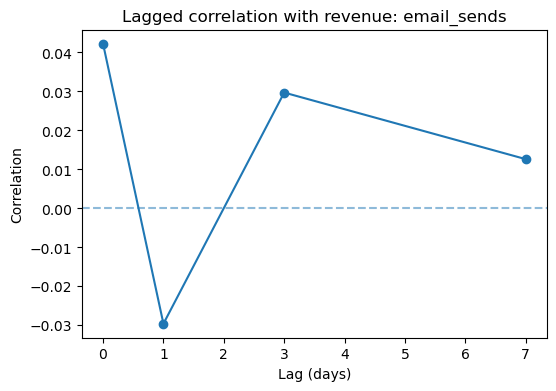

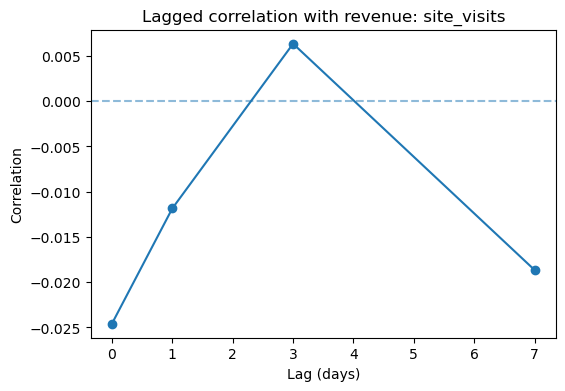

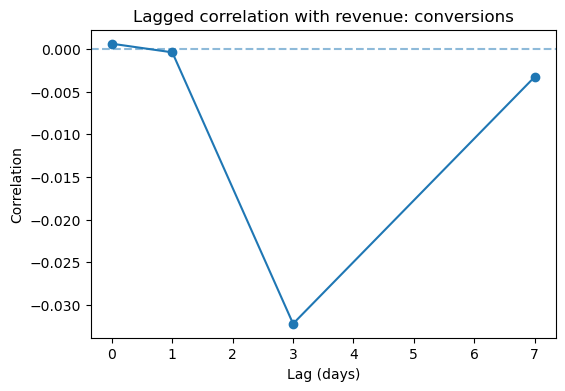

In [21]:
import matplotlib.pyplot as plt

for var in base_vars:
    lags = [0, 1, 3, 7]
    corrs = [
        df_clean[var].corr(df_clean["revenue"]),
        df_clean[f"{var}_lag1"].corr(df_clean["revenue"]),
        df_clean[f"{var}_lag3"].corr(df_clean["revenue"]),
        df_clean[f"{var}_lag7"].corr(df_clean["revenue"]),
    ]
    
    plt.figure(figsize=(6,4))
    plt.plot(lags, corrs, marker="o")
    plt.axhline(0, linestyle="--", alpha=0.5)
    plt.title(f"Lagged correlation with revenue: {var}")
    plt.xlabel("Lag (days)")
    plt.ylabel("Correlation")
    plt.show()

In [23]:
missing_lag_cols = [c for c in df_clean.columns if c.endswith("_missing") and "_lag" in c]

df_clean[missing_lag_cols + ["revenue"]].corr()["revenue"].sort_values(key = abs, ascending= False)

revenue                                   1.000000
email_marketing_spend_log_lag1_missing   -0.067982
conversions_lag1_missing                 -0.067982
site_visits_lag1_missing                 -0.067982
email_sends_lag1_missing                 -0.067982
influencer_spend_log_lag1_missing        -0.067982
google_ads_spend_log_lag1_missing        -0.067982
organic_traffic_lag1_missing             -0.067982
facebook_ads_spend_log_lag1_missing      -0.067982
organic_traffic_lag3_missing             -0.022634
conversions_lag3_missing                 -0.022634
site_visits_lag3_missing                 -0.022634
facebook_ads_spend_log_lag3_missing      -0.022634
email_marketing_spend_log_lag3_missing   -0.022634
google_ads_spend_log_lag3_missing        -0.022634
influencer_spend_log_lag3_missing        -0.022634
email_sends_lag3_missing                 -0.022634
organic_traffic_lag7_missing             -0.013222
email_marketing_spend_log_lag7_missing   -0.013222
email_sends_lag7_missing       